# Autoencoder for Image Denoising using MNIST

# Step 1: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

 # Step 2: Load the MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Step 3: Explore the Dataset

In [3]:
print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


# Step 4: Display Sample Images

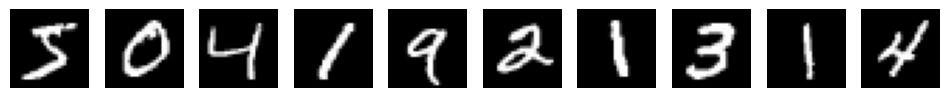

In [4]:
plt.figure(figsize=(12,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

# Step 5: Normalize the Images

In [5]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Before normalization:")
print(x_train.min(), x_train.max())

Before normalization:
0 255


In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("After normalization:")
print("Min:", x_train.min())
print("Max:", x_train.max())

After normalization:
Min: 0.0
Max: 1.0


# Step 6: Reshape the Images

In [7]:
x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test, (len(x_test),28,28,1))

print(x_train.shape)

(60000, 28, 28, 1)


# Step 7: Add Gaussian Noise

In [8]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

# Step 8: Visualize Noisy Images


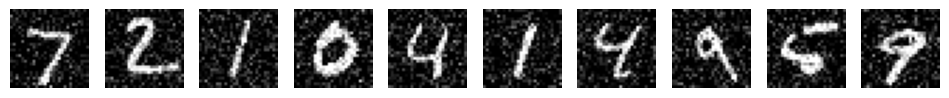

In [9]:
plt.figure(figsize=(12,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# Step 9: Build the Convolutional Autoencoder

In [10]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img, decoded)

# Step 10: Model Summary

The summary displays all layers, output shapes, and trainable parameters of the autoencoder.

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

# Step 11: Compile the Model

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Step 12: Train the Autoencoder

In [13]:
 history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.1329 - val_loss: 0.0838
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - loss: 0.0816 - val_loss: 0.0788
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - loss: 0.0781 - val_loss: 0.0763
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - loss: 0.0764 - val_loss: 0.0751
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - loss: 0.0754 - val_loss: 0.0744
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0746 - val_loss: 0.0737
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - loss: 0.0741 - val_loss: 0.0734
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0736 - val_loss: 0.0732
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - loss: 0.0732 - val_loss: 0.0727
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - loss: 0.0729 - val_loss: 0.0725
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 0.0726 - val_loss: 0.0720
Epoch 12/20
469/469 ━━━━━━━━━━

# Step 13: Generate Denoised Images

In [14]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


# Step 14: Compare the Results

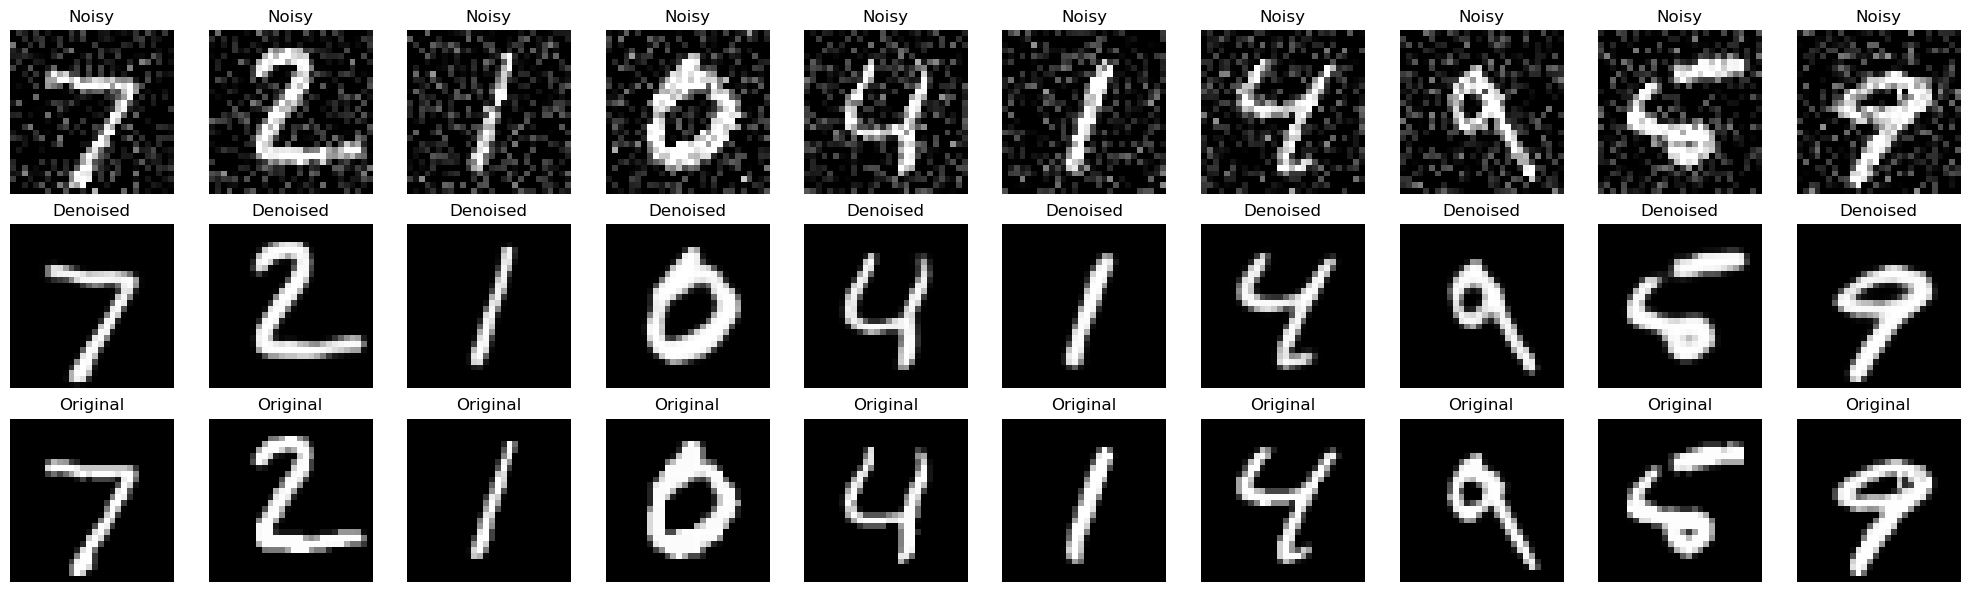

In [15]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Step 15: Plot Training and Validation Loss

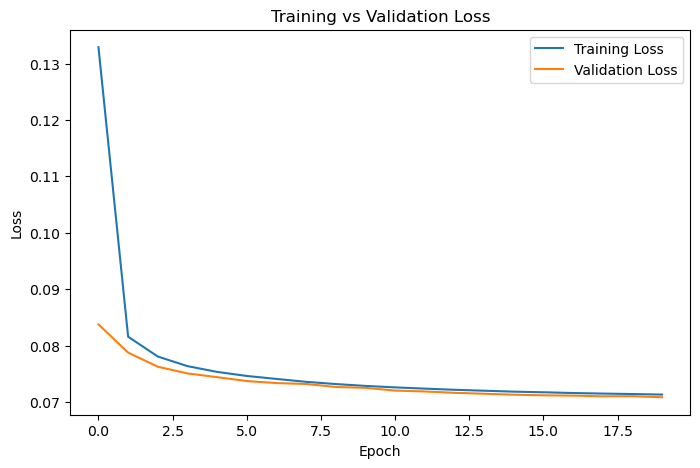

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# Step 16: Model Evaluation

The denoising performance of the autoencoder is evaluated using quantitative metrics.

- **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed and original images. Lower values indicate better reconstruction.

- **Peak Signal-to-Noise Ratio (PSNR):** Measures the quality of the reconstructed image. Higher values indicate better denoising performance.

In [17]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.reshape(-1),
    decoded_imgs.reshape(-1)
)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.0032743018


In [18]:
import tensorflow as tf

psnr = tf.image.psnr(decoded_imgs, x_test, max_val=1.0)
print("Average PSNR:", tf.reduce_mean(psnr).numpy())

Average PSNR: 25.184416


# Conclusion

A convolutional autoencoder was successfully implemented to perform image denoising on the MNIST handwritten digit dataset.

The model learned meaningful latent representations and reconstructed clean images from noisy inputs with high accuracy. The training and validation losses decreased consistently throughout training, indicating effective learning without overfitting.

The final evaluation metrics were:

- Training Loss: **0.0715**
- Validation Loss: **0.0711**
- Mean Squared Error (MSE): **0.00327**
- Average PSNR: **25.18 dB**

These results demonstrate that the proposed autoencoder effectively removes Gaussian noise while preserving the important features of handwritten digits.